## Corporación Favorita Grocery Sales Forecasting-Datensatz

Ablaufplan
Schritt 1: Fehlende Werte prüfen
Schritt 2: Ausreißer behandeln
Schritt 3: Fehlende Datumswerte mit Null-Umsatz auffüllen
Schritt 4: Feature Engineering – aus Datum nützliche Signale ableiten
Schritt 5: Zeitreihen visualisieren
Schritt 6: Einfluss von Feiertagen untersuchen
Schritt 7: Verderbliche Artikel analysieren

In [1]:
import pandas as pd

In [2]:
data=pd.read_csv('timeseries.csv')

In [3]:
data.head()

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        452 non-null    str    
 1   unit_sales  452 non-null    float64
dtypes: float64(1), str(1)
memory usage: 7.2 KB


In [5]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)  # Set 'date' as the index
missing_values = data.isnull().sum() #missing values?

In [6]:
missing_values

unit_sales    0
dtype: int64

In [7]:
# Check if all days are vorhanden
date_range = pd.date_range(start=data.index.min(), end=data.index.max())
missing_dates = date_range.difference(data.index)
missing_dates

DatetimeIndex(['2013-12-25', '2014-01-01'], dtype='datetime64[us]', freq=None)

In [8]:
# 2 fehlen -> auffüllen mit den fehlenden Werten
data = data.reindex(date_range)
data['unit_sales'] = data['unit_sales'].ffill() #keine ahnung womit die jetzt aufgefüllt werden.. mit NAN?

In [9]:
holidays = pd.read_csv('holidays.csv')
oil= pd.read_csv('oil.csv')
stores=pd.read_csv('stores.csv')

In [10]:
holidays.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         350 non-null    str  
 1   locale       350 non-null    str  
 2   locale_name  350 non-null    str  
 3   description  350 non-null    str  
dtypes: str(4)
memory usage: 11.1 KB


In [11]:
'''# bei holidays funktioniert das nicht, die sind und müssen unzusammenhängend sein...
holidays['date'] = pd.to_datetime(holidays['date'])
holidays.set_index('date', inplace=True)
date_range_h = pd.date_range(start=holidays.index.min(), end=holidays.index.max())
date_range_h.difference(holidays.index)
'''

"# bei holidays funktioniert das nicht, die sind und müssen unzusammenhängend sein...\nholidays['date'] = pd.to_datetime(holidays['date'])\nholidays.set_index('date', inplace=True)\ndate_range_h = pd.date_range(start=holidays.index.min(), end=holidays.index.max())\ndate_range_h.difference(holidays.index)\n"

In [12]:
oil.info()

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   str    
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), str(1)
memory usage: 19.2 KB


In [13]:
oil['date'] = pd.to_datetime(oil['date'])
oil.set_index('date', inplace=True)
date_range_o = pd.date_range(start=oil.index.min(), end=oil.index.max())
date_range_o.difference(oil.index)

DatetimeIndex(['2013-01-05', '2013-01-06', '2013-01-12', '2013-01-13',
               '2013-01-19', '2013-01-20', '2013-01-26', '2013-01-27',
               '2013-02-02', '2013-02-03',
               ...
               '2017-07-29', '2017-07-30', '2017-08-05', '2017-08-06',
               '2017-08-12', '2017-08-13', '2017-08-19', '2017-08-20',
               '2017-08-26', '2017-08-27'],
              dtype='datetime64[us]', length=486, freq=None)

In [14]:
oil_ = data.reindex(date_range)
oil_['dcoilwtico'] = oil['dcoilwtico'].ffill()

In [15]:
#%pip install DARTS

In [16]:
#import DARTS

ModuleNotFoundError: No module named 'DARTS'

In [ ]:
#%pip install seaborn

In [18]:
from darts import TimeSeries
series = TimeSeries.from_dataframe(data, value_cols='unit_sales')

In [19]:
import matplotlib.pyplot as plt

<Axes: xlabel='time'>

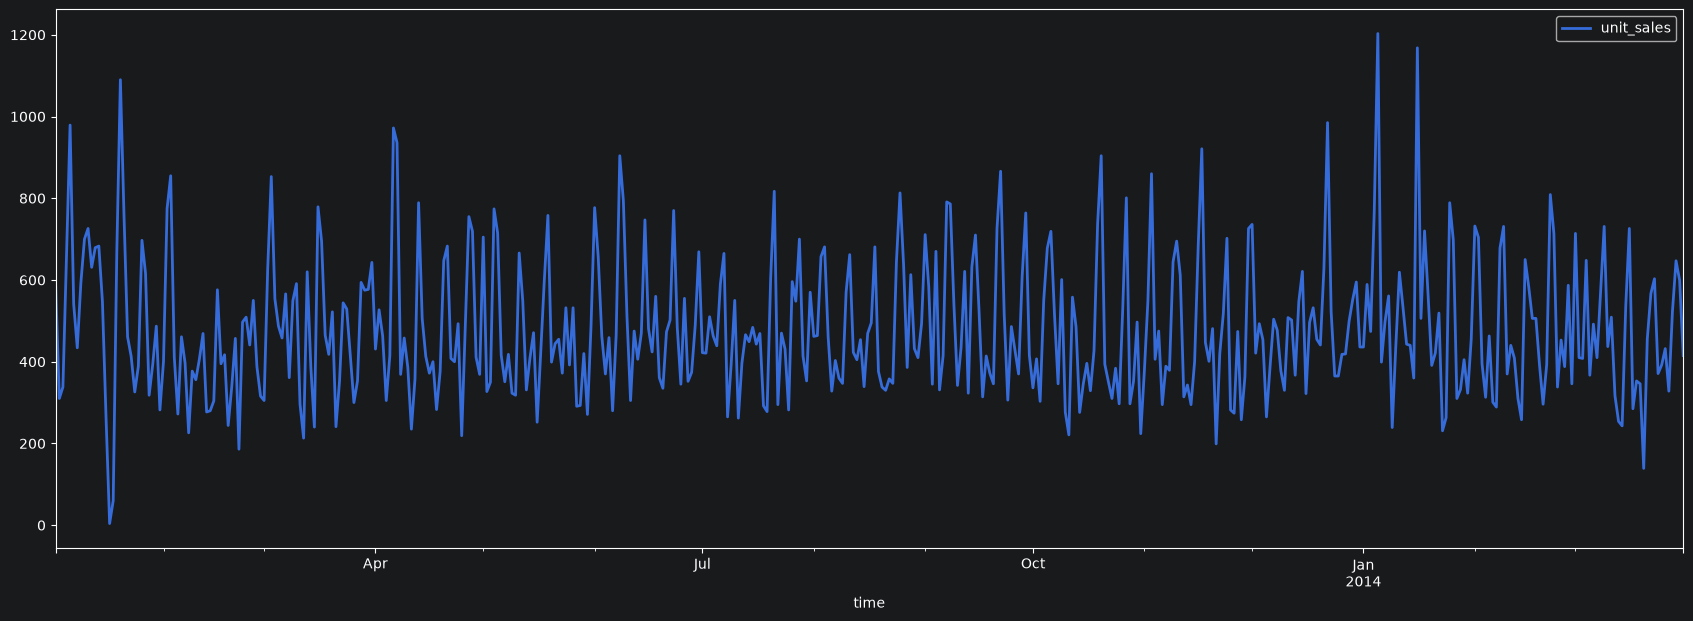

In [20]:
# Visualisiere die gefilterten Verkaufsdaten
plt.figure(figsize=(21, 7))  # Größe der Abbildung anpassen (Breite, Höhe)
series.plot()

In [21]:
# Daten aufteilen (80% Training, 20% Test)
train, test = series.split_after(0.8)

### für ARIMA / SARIMA

In [22]:
from darts.models import ARIMA

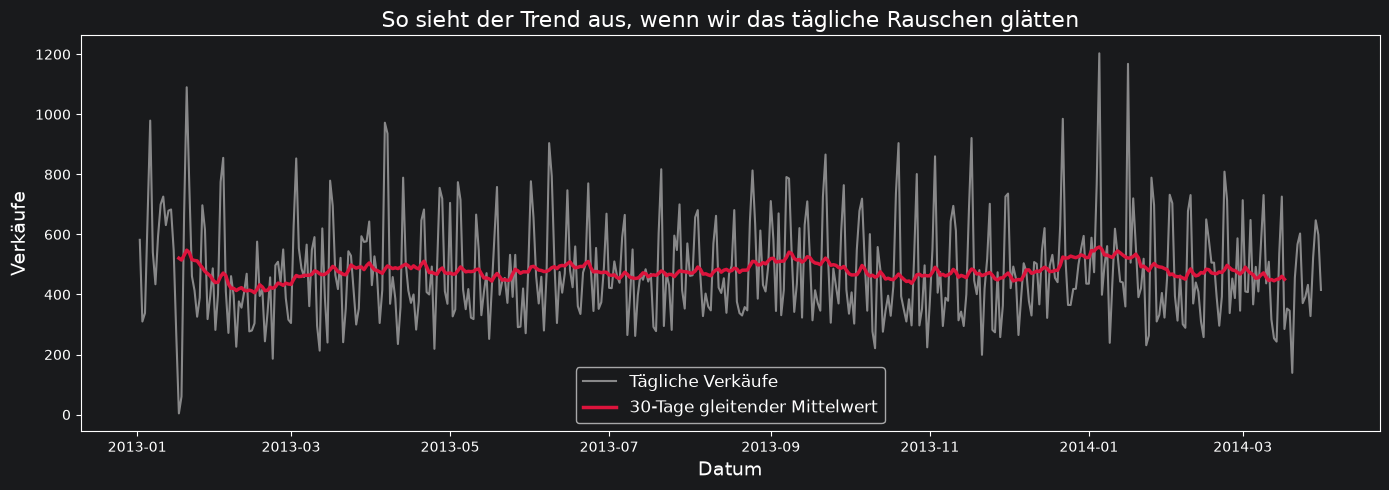

In [25]:
# Berechne gleitenden 30-Tage-Mittelwert zur Glättung
rolling_trend = data['unit_sales'].rolling(window=30, center=True).mean()

plt.figure(figsize=(14, 5))
# Zeichne die täglichen Verkaufszahlen in hellgrau
plt.plot(data.index, data['unit_sales'],
         color='lightgray', alpha=0.6, label='Tägliche Verkäufe')

# Zeichne den gleitenden Mittelwert in kräftigem Rot
plt.plot(rolling_trend.index, rolling_trend.values,
         color='crimson', linewidth=2.5, label='30-Tage gleitender Mittelwert')

plt.title("So sieht der Trend aus, wenn wir das tägliche Rauschen glätten", fontsize=16)
plt.xlabel("Datum", fontsize=14)
plt.ylabel("Verkäufe", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [32]:
#ADF Test für stationär. Nullhypothese ist nicht stationär, wenn p>0,05
from statsmodels.tsa.stattools import adfuller

# adfuller() funktioniert nicht direkt mit Darts TimeSeries –
# wir müssen die Werte extrahieren:
arr = train.values().flatten()   # Bei univariater Serie in 1D umwandeln

# ADF-Test ausführen
result = adfuller(arr)
print(result[1])
#print(f"ADF p-value: {p:.2e}")

0.0006351558691093032


In [30]:
import numpy as np

In [33]:
''' Muss ich hier nicht machen weil p wert kleiner als 0,05
# Führe die erste Differenzierung durch – das ist unsere neue differenzierte Trainingsreihe
diff1 = np.diff(arr, 1)
# ADF-Test auf der differenzierten Serie
result = adfuller(diff1)
print("p-Wert der 1. Differenzierung:", result[1])
'''

p-Wert der 1. Differenzierung: 4.030957162375594e-12


d Wert für ARIMA ist 0, weil Daten stationär sind

In [ ]:
#hjvjhhjvhvgbvdsxv xc